In [17]:
import importlib
import plots
import feature_mining

importlib.reload(plots)
importlib.reload(feature_mining)

import pandas as pd

from plots import *
from feature_mining import *

#### Load labeled dataset

In [18]:
df = pd.read_csv("../data/ait_ads/labeled_combined_ait.csv", low_memory=False)
df.columns

# make sure timestamps are datetime and sorted
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

#### Set run name and min_support parameter

In [19]:
run_name="3-itemset_mining"
output_dir = f"../plots/{run_name}"
os.makedirs(output_dir,exist_ok=True)
min_support=50

#### Normalize `category`

In [20]:
df["category_norm"] = df["category"].astype(str).str.split(" - ").str[0].str.strip()

In [21]:
df["category_norm"].value_counts()

category_norm
Suricata: Alert                                                              306635
IDS event.                                                                   295032
Multiple IDS alerts for same id.                                               7036
AMiner: New event type.                                                        5787
Multiple IDS events from same source ip.                                       2362
Apache: Attempt to access forbidden file or directory.                         2353
Multiple IDS alerts for same id (ignoring now this id).                        1465
First time this IDS alert is generated.                                         626
AMiner: New user_acct parameter combination in Audit logs.                      354
Apache: Attempt to access forbidden directory index.                            338
AMiner: New user_auth parameter combination in Audit logs.                      300
Multiple IDS events from same source ip (ignoring now this src

### Window based mining run (scenario local)

##### Token mining (transactional)

In [22]:
scorer_name = "contrast"
miner_name = "token"

In [23]:
scenario_rankings, scenario_attack_flags = window_based_mining(
    df,
    scorer=fp_contrast_scorer(alpha=0.5),
    counter=mine_itemset_counts,
    counter_kwargs={"k":3, "min_support": min_support}
)

# scenario_rankings, scenario_attack_flags = window_based_mining(
#     df,
#     scorer=fp_contrast_scorer(alpha=0.5),
#     counter=mine_token_counts,
# )

running mining for scenario santos....
Window [2022-01-14 00:00:00+00:00, 2022-01-14 12:00:00+00:00)
  Benign alerts : 15595
  Attack alerts : 0
  Total alerts  : 15595


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-01-14 12:00:00+00:00, 2022-01-15 00:00:00+00:00)
  Benign alerts : 16461
  Attack alerts : 0
  Total alerts  : 16461
Window [2022-01-15 00:00:00+00:00, 2022-01-15 12:00:00+00:00)
  Benign alerts : 16682
  Attack alerts : 0
  Total alerts  : 16682
Window [2022-01-15 12:00:00+00:00, 2022-01-16 00:00:00+00:00)
  Benign alerts : 15804
  Attack alerts : 0
  Total alerts  : 15804
Window [2022-01-16 00:00:00+00:00, 2022-01-16 12:00:00+00:00)
  Benign alerts : 11844
  Attack alerts : 0
  Total alerts  : 11844
Window [2022-01-16 12:00:00+00:00, 2022-01-17 00:00:00+00:00)
  Benign alerts : 3153
  Attack alerts : 0
  Total alerts  : 3153
Window [2022-01-17 00:00:00+00:00, 2022-01-17 12:00:00+00:00)
  Benign alerts : 3103
  Attack alerts : 60
  Total alerts  : 3163
Window [2022-01-17 12:00:00+00:00, 2022-01-18 00:00:00+00:00)
  Benign alerts : 5753
  Attack alerts : 0
  Total alerts  : 5753
running mining for scenario fox....
Window [2022-01-15 00:00:00+00:00, 2022-01-15 12:00:00+00:0

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-01-16 00:00:00+00:00, 2022-01-16 12:00:00+00:00)
  Benign alerts : 2368
  Attack alerts : 0
  Total alerts  : 2368
Window [2022-01-16 12:00:00+00:00, 2022-01-17 00:00:00+00:00)
  Benign alerts : 3112
  Attack alerts : 0
  Total alerts  : 3112
Window [2022-01-17 00:00:00+00:00, 2022-01-17 12:00:00+00:00)
  Benign alerts : 1788
  Attack alerts : 2
  Total alerts  : 1790
Window [2022-01-17 12:00:00+00:00, 2022-01-18 00:00:00+00:00)
  Benign alerts : 2053
  Attack alerts : 0
  Total alerts  : 2053
Window [2022-01-18 00:00:00+00:00, 2022-01-18 12:00:00+00:00)
  Benign alerts : 1563
  Attack alerts : 0
  Total alerts  : 1563
Window [2022-01-18 12:00:00+00:00, 2022-01-19 00:00:00+00:00)
  Benign alerts : 3947
  Attack alerts : 149
  Total alerts  : 4096
Window [2022-01-19 00:00:00+00:00, 2022-01-19 12:00:00+00:00)
  Benign alerts : 2360
  Attack alerts : 0
  Total alerts  : 2360
Window [2022-01-19 12:00:00+00:00, 2022-01-20 00:00:00+00:00)
  Benign alerts : 2737
  Attack alerts :

...

Window [2022-01-26 00:00:00+00:00, 2022-01-26 12:00:00+00:00)
  Benign alerts : 14970
  Attack alerts : 0
  Total alerts  : 14970
Window [2022-01-26 12:00:00+00:00, 2022-01-27 00:00:00+00:00)
  Benign alerts : 10942
  Attack alerts : 0
  Total alerts  : 10942
Window [2022-01-27 00:00:00+00:00, 2022-01-27 12:00:00+00:00)
  Benign alerts : 11489
  Attack alerts : 0
  Total alerts  : 11489
Window [2022-01-27 12:00:00+00:00, 2022-01-28 00:00:00+00:00)
  Benign alerts : 16570
  Attack alerts : 0
  Total alerts  : 16570
Window [2022-01-28 00:00:00+00:00, 2022-01-28 12:00:00+00:00)
  Benign alerts : 12787
  Attack alerts : 0
  Total alerts  : 12787
Window [2022-01-28 12:00:00+00:00, 2022-01-29 00:00:00+00:00)
  Benign alerts : 14782
  Attack alerts : 0
  Total alerts  : 14782
Window [2022-01-29 00:00:00+00:00, 2022-01-29 12:00:00+00:00)
  Benign alerts : 10264
  Attack alerts : 222
  Total alerts  : 10486
Window [2022-01-29 12:00:00+00:00, 2022-01-30 00:00:00+00:00)
  Benign alerts : 17752
  

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-02-03 12:00:00+00:00, 2022-02-04 00:00:00+00:00)
  Benign alerts : 13592
  Attack alerts : 0
  Total alerts  : 13592
Window [2022-02-04 00:00:00+00:00, 2022-02-04 12:00:00+00:00)
  Benign alerts : 10164
  Attack alerts : 0
  Total alerts  : 10164
Window [2022-02-04 12:00:00+00:00, 2022-02-05 00:00:00+00:00)
  Benign alerts : 13294
  Attack alerts : 0
  Total alerts  : 13294
Window [2022-02-05 00:00:00+00:00, 2022-02-05 12:00:00+00:00)
  Benign alerts : 11782
  Attack alerts : 0
  Total alerts  : 11782
Window [2022-02-05 12:00:00+00:00, 2022-02-06 00:00:00+00:00)
  Benign alerts : 10983
  Attack alerts : 0
  Total alerts  : 10983
Window [2022-02-06 00:00:00+00:00, 2022-02-06 12:00:00+00:00)
  Benign alerts : 10114
  Attack alerts : 0
  Total alerts  : 10114
Window [2022-02-06 12:00:00+00:00, 2022-02-07 00:00:00+00:00)
  Benign alerts : 12632
  Attack alerts : 0
  Total alerts  : 12632
Window [2022-02-07 00:00:00+00:00, 2022-02-07 12:00:00+00:00)
  Benign alerts : 9690
  Att

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Window [2022-02-04 12:00:00+00:00, 2022-02-05 00:00:00+00:00)
  Benign alerts : 17623
  Attack alerts : 0
  Total alerts  : 17623
Window [2022-02-05 00:00:00+00:00, 2022-02-05 12:00:00+00:00)
  Benign alerts : 13133
  Attack alerts : 0
  Total alerts  : 13133
Window [2022-02-05 12:00:00+00:00, 2022-02-06 00:00:00+00:00)
  Benign alerts : 15026
  Attack alerts : 0
  Total alerts  : 15026
Window [2022-02-06 00:00:00+00:00, 2022-02-06 12:00:00+00:00)
  Benign alerts : 12895
  Attack alerts : 0
  Total alerts  : 12895
Window [2022-02-06 12:00:00+00:00, 2022-02-07 00:00:00+00:00)
  Benign alerts : 14577
  Attack alerts : 0
  Total alerts  : 14577
Window [2022-02-07 00:00:00+00:00, 2022-02-07 12:00:00+00:00)
  Benign alerts : 14180
  Attack alerts : 0
  Total alerts  : 14180
Window [2022-02-07 12:00:00+00:00, 2022-02-08 00:00:00+00:00)
  Benign alerts : 14986
  Attack alerts : 0
  Total alerts  : 14986
Window [2022-02-08 00:00:00+00:00, 2022-02-08 12:00:00+00:00)
  Benign alerts : 15300
  At

#### Heat map for given scenario to show the contrast score of each token over all windows in the scenario

In [24]:
# find min and max global score so we can set a fixed colour scale for all scenario heatmaps
def compute_global_score_limits(scenario_rankings, score_col="score"):
    max_abs = 0.0
    for rankings in scenario_rankings.values():
        for ranking_k in rankings:
            if score_col in ranking_k.columns:
                max_abs = max(max_abs, np.abs(ranking_k[score_col]).max())
    return -max_abs, max_abs

vmin_global, vmax_global = compute_global_score_limits(scenario_rankings)
print(vmin_global, vmax_global)

-8.852664927703866 8.852664927703866


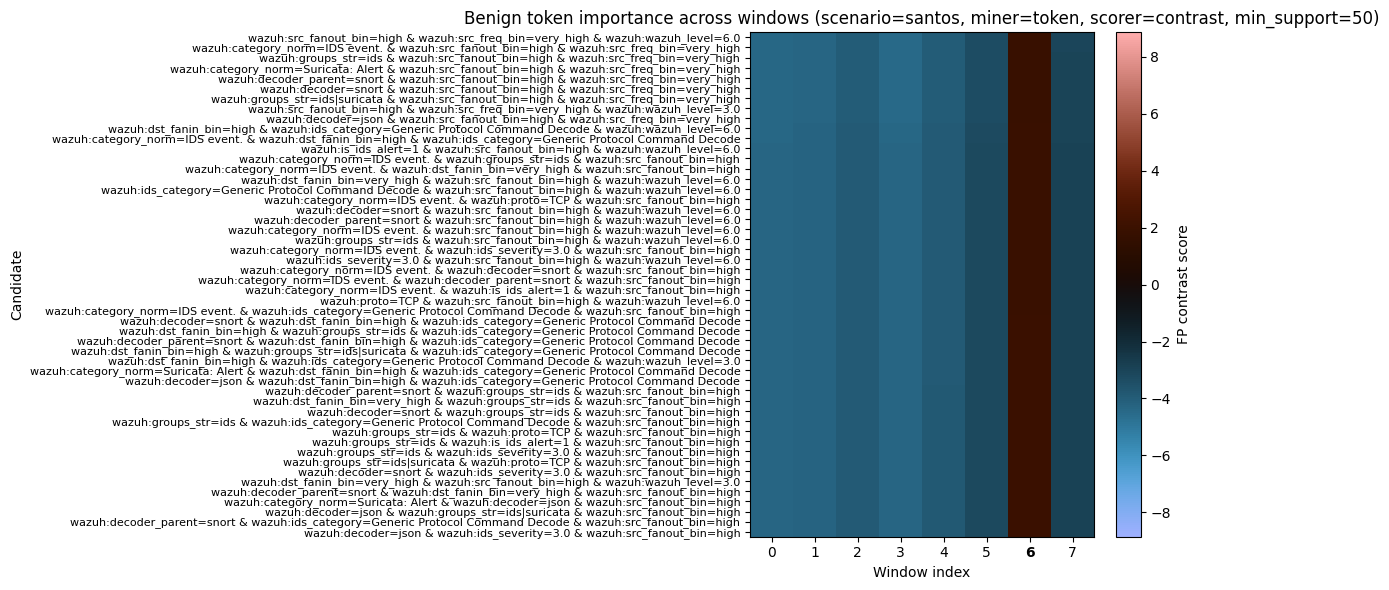

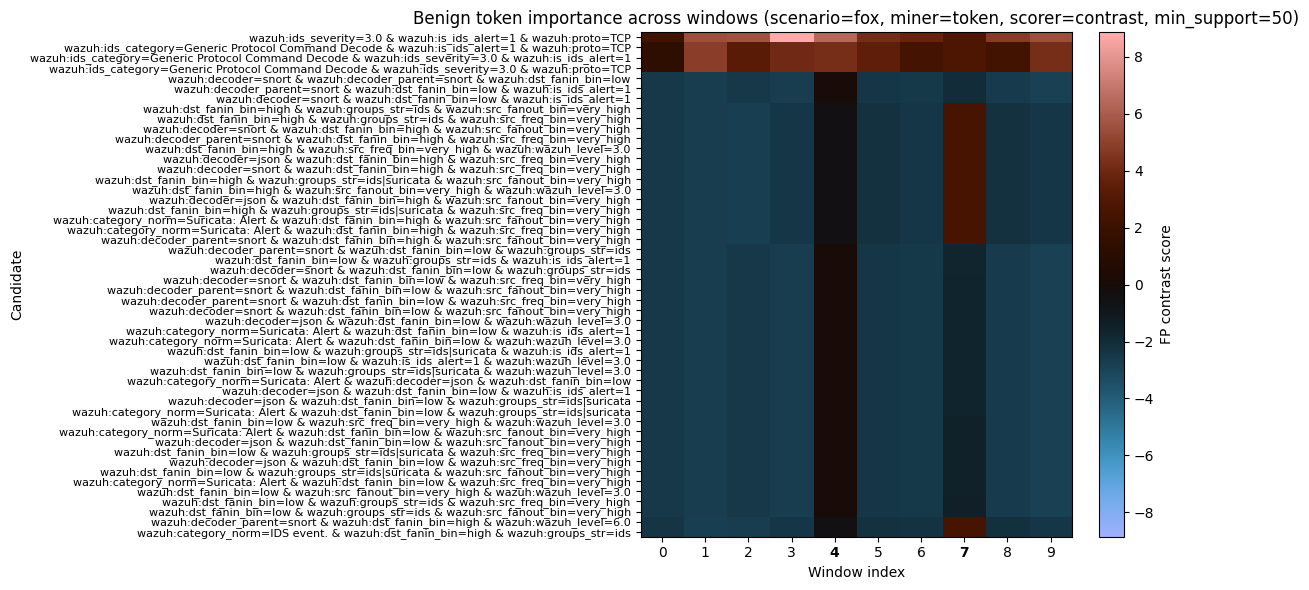

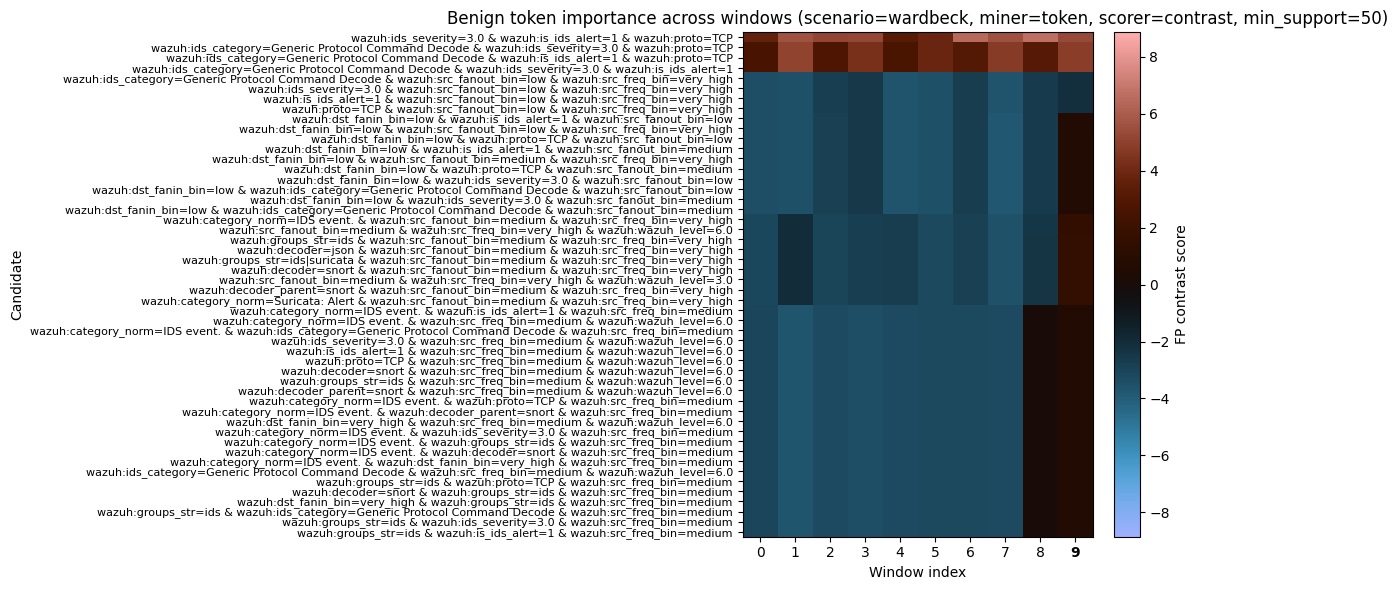

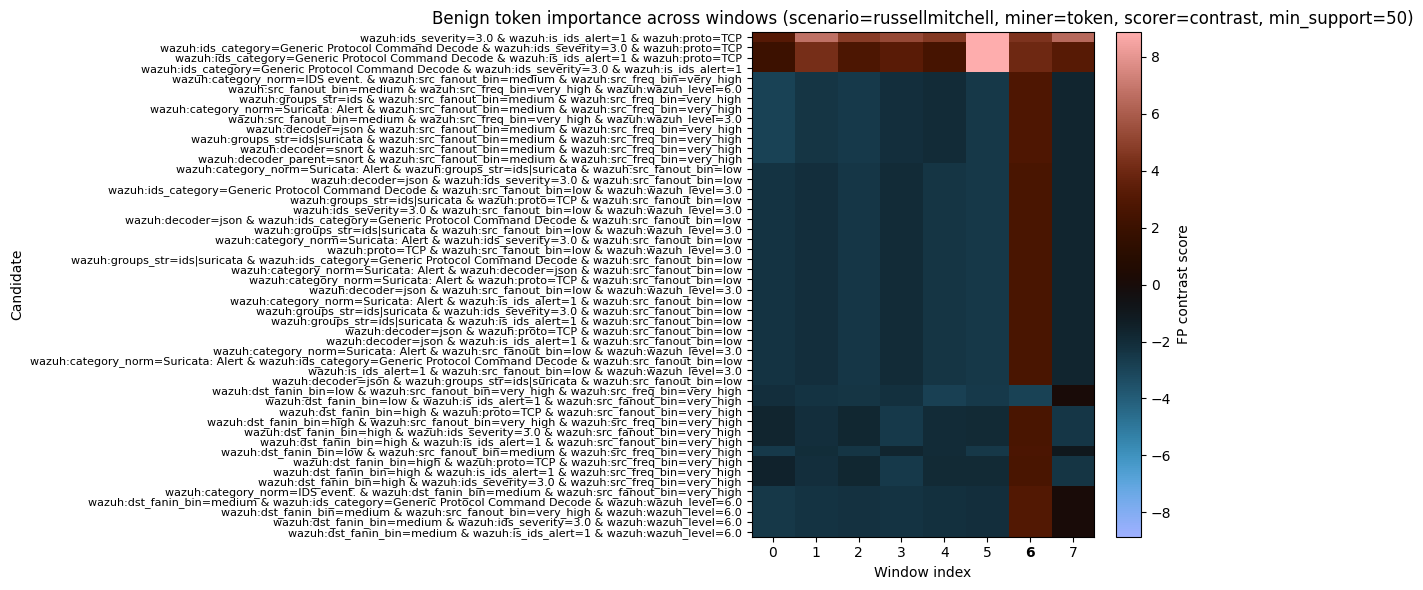

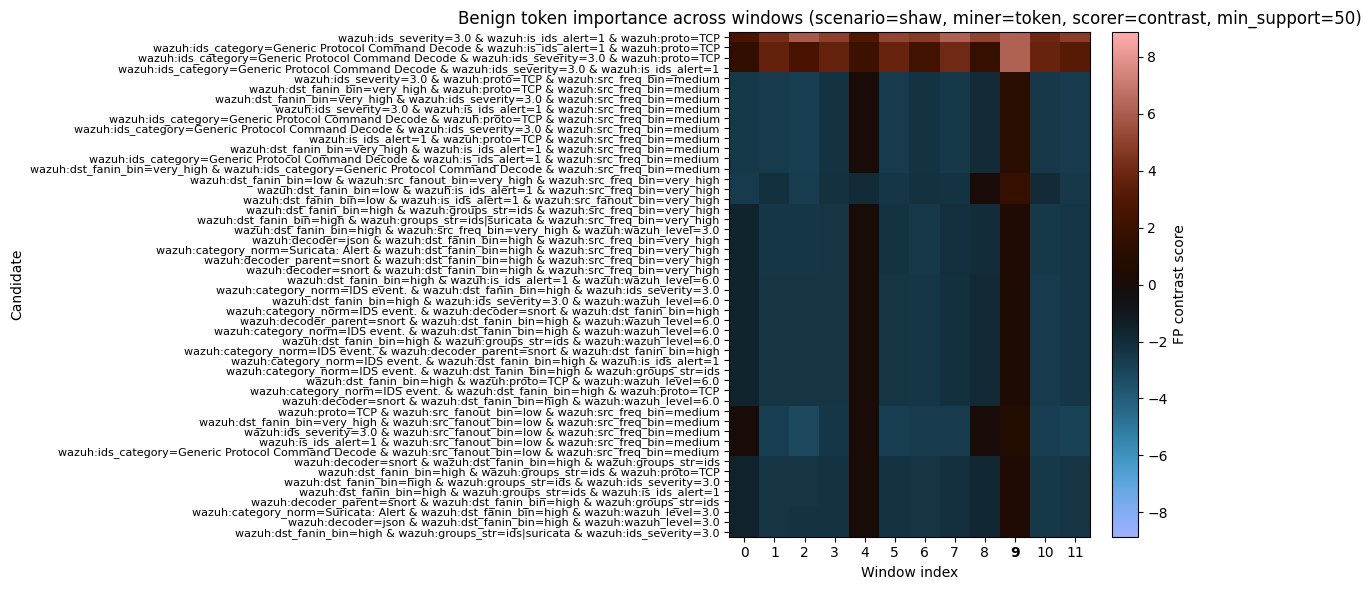

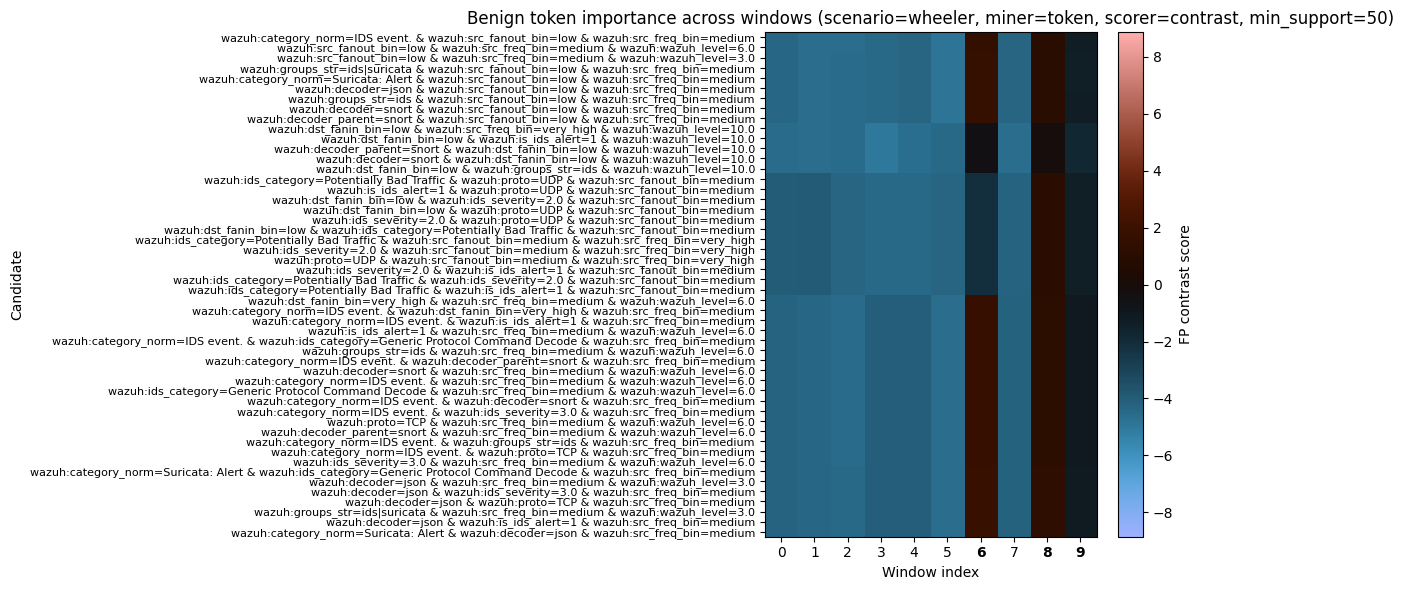

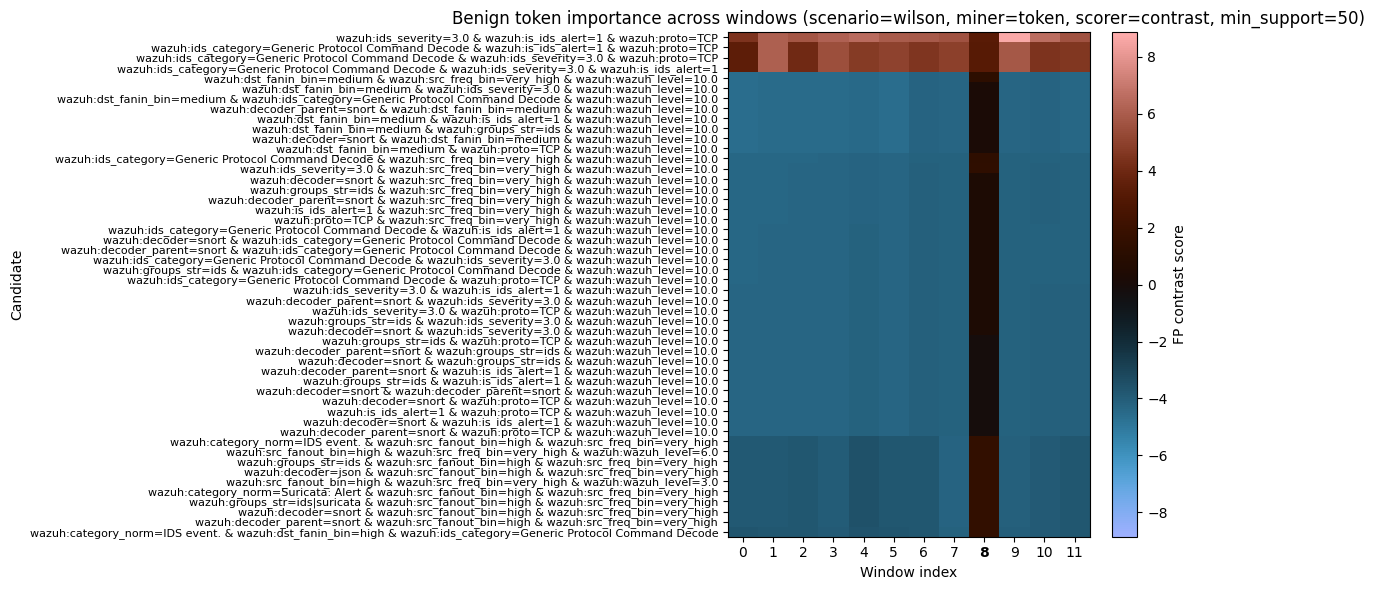

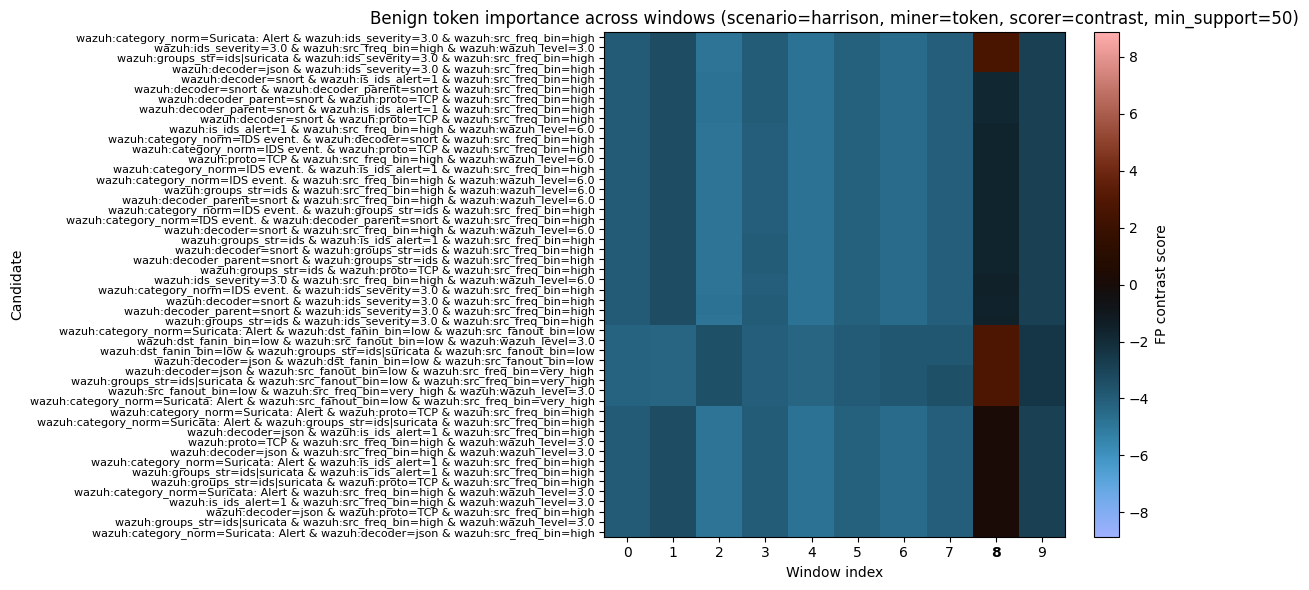

In [25]:
for scenario, df_s in df.groupby("scenario", sort=False):
    rankings = scenario_rankings.get(scenario)
    flags = scenario_attack_flags.get(scenario)
    plot_scenario_heatmap(rankings, flags, output_dir, scenario, miner_name, scorer_name, min_support, top_n=50, vmin=vmin_global, vmax=vmax_global)